# DEF-D Fysieke Ontwerpopdracht 5 Invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 44    |  |
| :-------------|:-------------|
| Isha Schneiders| 6384838 |
| Casper Jansen| 6265200 |
| Abenezer Bayu| 6268315 |

## Opdracht 1: Planning.

| Planning Groep: 44     |Tijdstip / Tijdspanne  | door wie  |
|---|---|---|
| Arduino testen| 11.30 | Casper |
| ontwerp-eis berekenen| 11.30 | Isha en Abenezer |
| schets + ontwerp + synthese | 12.30 | hele groep |
| simulatie  | 13.30-13.45 | hele groep |
| bouwen  | 13.45-14.45 | hele groep |
| meten  | 14.45-15.45 | hele groep |
| iteratrie  | 15.45-16.45 | hele groep |
| Pauze 1| TU pauze | hele groep |


Run onderstaande cel om alle benodigde libraries te laden. Mogelijk voeg je er zelf nog een aantal toe later vandaag. 

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
import math

## Opdracht 2a: Opsplitsen taak 1: Arduino
Vul onderstaande tabel in:

| onderwerp    | antwoord  |
|---|---|
| hoe moeilijk (schaal 1 - 10) | 7 |
| hoe lang voor één meting | 5  min max |
| verwacht nauwkeurigheid meting | frequentie: 0.1 Hz, amplitude: 0.2 cm |

## Opdracht 2b: Opsplitsen taak 2: afleiding ontwerpeis

In [2]:
# Bereken hier je benodigde kantelfrequentie
#voor 5hz en 3x demping geld:
f0=5 #Hz
w0=2*np.pi*f0 #hz
w_c=w0/2 #Hz
f_c=w_c/(2*np.pi)
print(f_c)

2.5


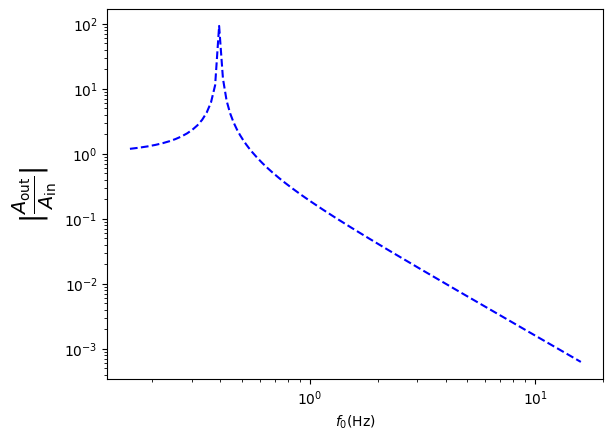

In [3]:
# Voeg hier je plot in.
def Aout_Ain(f0,w_c):
    '''
    Functie Aout/Ain volgend dictaat
    w0 = grondfrequantie in Hertz
    w_c = eigenfrequentie in Hertz
    '''
    return np.abs(1/(1-(2*np.pi*f0/w_c)**2))

w0_arr=np.linspace(1,100,1000) #grondfrequenties 

#plot
plt.figure()
plt.plot(w0_arr/(2*np.pi),Aout_Ain(w0_arr,w_c),"b--")
plt.ylabel(r"|$\frac{A_\text{out}}{A_\text{in}}$|",fontsize=20)
plt.xlabel(r"$f_0$(Hz)")
plt.loglog()
plt.show()

In [4]:
# Bereken hier de minimale Delta-x waarbij je aan de eis van de opdracht voldoet.
#dx=g/w_c**2 geeft:
g=9.812 #m/s^2
delta_x=g/w_c**2 #m
print(f"{delta_x*100:.2f} cm")

3.98 cm


## Opdracht 3: Plot de grafiek.

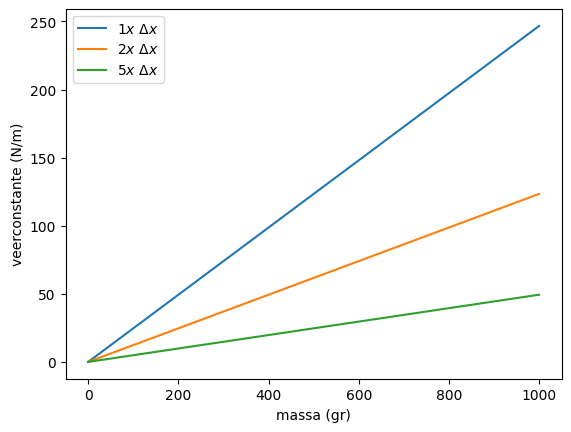

In [5]:
# Voeg hier je plot in. Lees goed de opdracht wat er in de grafiek moet staan!
# Het is ook handig om je grafiek op te slaan, doe dat door met plt.savefig().
def c_func(m,delta_x):
    """ veerconstante als fuctie van massa"""
    return (g/delta_x)*m/1000 #geddeld door 1000 voor invoerwaarde vn kilo

#plotten:
m_plot=np.linspace(0,1000,1000)#massa in gr 
plt.figure()
plt.plot(m_plot,c_func(m_plot,delta_x),label=r"$1x \ \Delta x$")
plt.plot(m_plot,c_func(m_plot,2*delta_x),label=r"$2x \ \Delta x$")
plt.plot(m_plot,c_func(m_plot,5*delta_x),label=r"$5x \ \Delta x$")
plt.xlabel("massa (gr)")
plt.ylabel("veerconstante (N/m)")
plt.legend()
#plt.savefig("opdr3_verband_c_m")
plt.show()



## Opdracht 4: Verander $\Delta x$.

We kunnen $\Delta x$ verhogen door:

- massa vergroten
- veerconsatnte verkleinen

Vul onderstaande aan. Geef eventueel met tekst aan waarom je hiervoor gekozen hebt, als extra informatie richting de nakijkers. 

Als groep gaan we mikken op een $\Delta x$ van: 6cm 

## Opdracht 5: Schets.

##### schets opstelling: 
<img src="schetstrillingvrij.jpeg" width="400">

## Opdracht 6: Beslissing evaluatie

In [6]:
#veerconatnte veer
def veerconstante(m,g,L,L_0):
    return m*g/((L-L_0)*1e-2)

m_schaar= 29.3e-3 #massa in kg
c_1=veerconstante(m_schaar,g,10.2,2.7) #veerconstante
c_2= veerconstante(m_schaar,g,11.5,6.1)
c_3=veerconstante(m_schaar,g,11.7,7.5)
c_4=veerconstante(m_schaar,g,12.7,4.3)
c_tot=c_1+c_2+c_3+c_4

print("veerconstante 1",c_1)
delta_x_doel=6e-2 #m

m_min=((delta_x_doel*(c_tot)/g))*1e3
print("massa voor dx=6 cm is", m_min, "gr")

veerconstante 1 3.833221333333333
massa voor dx=6 cm is 118.78126984126985 gr


Voldoet je ontwerp aan de eisen? Beantwoord de volgende vragen: iteratie 1

### Wat is de $\Delta x$ van je ontwerp?

4 cm

### Wordt die $\Delta x$ behaald met je gekozen massa en veer?

nee

### hoeveel verder kan je massa-veer systeem nog uitrekken / indrukken?
Wat is de limiet aan je veer / verend materiaal voordat het niet meer lineair reageert volgens de wet van Hooke?

delta x van 25 cm

### Is dat genoeg om straks metingen te kunnen doen?
Hou er rekening mee dat je trillingen een amplitude in de orde grote van een paar centimeter gaan hebben, minder is met deze opzet moeilijk te realiseren.

nee

### Gaat je ontwerp dus voldoen aan de eis?

nee

Als je hier positief geantwoord heb, maak dan nog een keer een plot van amplitude overdracht (y-as) versus frequentie (x-as) zoals je hierboven ook al een keer gedaan heb, maar plot nu twee verschillende overdrachten in de grafiek: één die je al had: behorende bij de grens van de ontwerp-eis en één behorende bij je eigen ontwerp. Lees af dat je voor je ontwerp daadwerkelijk onder de eis grafiek zit op de kritieke frequentie!

Deze grafiek heb je later weer nodig om je gemeten punten aan toe te voegen. Ga daarna je massa-veer systeem daadwerkelijk bouwen.

Als je hier negatief geantwoord hebt, kopieer onder deze cel dan alle cellen van Synthese tot en met Evaluation & decision en doorloop dat deel van het ontwerp proces nogmaals.

#### nieuwe schets iteratie 2:
<img src="shcetiter2.jpeg" width="400">

In [7]:
delta_x_doel=14e-2 #m
c_tot=c_1+c_2+c_3+c_4
m_min=((delta_x_doel*(c_tot)/g))*1e3
print("min massa voor dx=14 cm is", m_min, "gr")

min massa voor dx=14 cm is 277.1562962962963 gr


Voldoet je ontwerp aan de eisen? Beantwoord de volgende vragen:

### Wat is de $\Delta x$ van je ontwerp?

14.6 cm

### Wordt die $\Delta x$ behaald met je gekozen massa en veer?

ja

### hoeveel verder kan je massa-veer systeem nog uitrekken / indrukken?
Wat is de limiet aan je veer / verend materiaal voordat het niet meer lineair reageert volgens de wet van Hooke?

delta x van 25 cm

### Is dat genoeg om straks metingen te kunnen doen?
Hou er rekening mee dat je trillingen een amplitude in de orde grote van een paar centimeter gaan hebben, minder is met deze opzet moeilijk te realiseren.

ja

### Gaat je ontwerp dus voldoen aan de eis?

ja

Als je hier positief geantwoord heb, maak dan nog een keer een plot van amplitude overdracht (y-as) versus frequentie (x-as) zoals je hierboven ook al een keer gedaan heb, maar plot nu twee verschillende overdrachten in de grafiek: één die je al had: behorende bij de grens van de ontwerp-eis en één behorende bij je eigen ontwerp. Lees af dat je voor je ontwerp daadwerkelijk onder de eis grafiek zit op de kritieke frequentie!

Deze grafiek heb je later weer nodig om je gemeten punten aan toe te voegen. Ga daarna je massa-veer systeem daadwerkelijk bouwen.

Als je hier negatief geantwoord hebt, kopieer onder deze cel dan alle cellen van Synthese tot en met Evaluation & decision en doorloop dat deel van het ontwerp proces nogmaals.

kantelfrequentie van de opstelling is berekend op 1.311409511498495 Hz


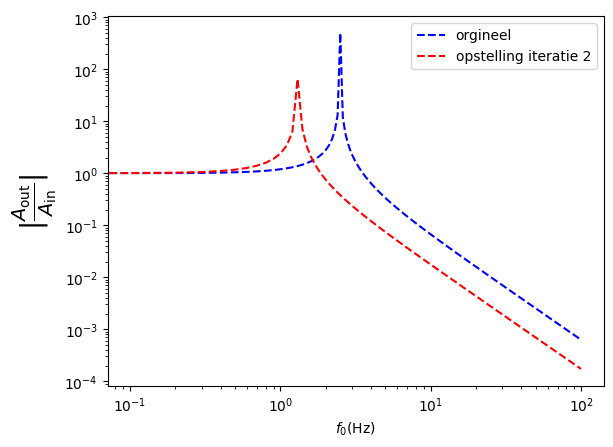

In [8]:
# Voeg hier je plot in.
m_ops=286.1*1e-3 #kg
w_c_ops=np.sqrt(c_tot/m_ops)
f_c_ops=w_c_ops/(2*np.pi) #H
print("kantelfrequentie van de opstelling is berekend op",f_c_ops,"Hz")

def Aout_Ain(f0,w_c):
    '''
    Functie Aout/Ain volgend dictaat
    w0 = grondfrequantie in Hertz
    w_c = eigenfrequentie in Hertz
    '''
    return np.abs(1/(1-(2*np.pi*f0/w_c)**2))

w0_arr=np.linspace(0,100,1000) #grondfrequenties 

#plot
plt.figure()
plt.plot(w0_arr,Aout_Ain(w0_arr,w_c),"b--",label="orgineel")
plt.plot(w0_arr,Aout_Ain(w0_arr,w_c_ops),"r--",label="opstelling iteratie 2")
plt.ylabel(r"|$\frac{A_\text{out}}{A_\text{in}}$|",fontsize=20)
plt.xlabel(r"$f_0$(Hz)")
plt.loglog()
plt.legend()
plt.show()

## Opdracht 7: Plotten maar

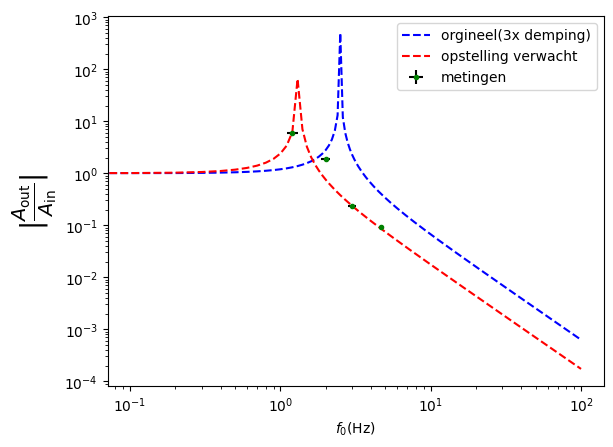

In [9]:
#meetwaarden
Ain=np.array([0.12,0.23,0.86,4.3]) #de grondamplitude/ plankamplitude
Aout=np.array([0.70,0.43,0.20,0.4]) #de amplitude van de opstelling
plank_frequenties=np.array([1.2,2.0,3.0,4.7]) #frequentie van de plank
#ops_frequenties=np.array([]) #frequentie van opstelling
Ain_Aout_meting=Aout/Ain


#plot
f_err=np.array([0.1,0.15,0.2,0.2]) #Hz
A_err=np.array([0.15,0.16,0.3,0.5])*1e-2 #m oftewel 0.2 cm
plt.figure()
plt.plot(w0_arr,Aout_Ain(w0_arr,w_c),"b--",label="orgineel(3x demping)")
plt.plot(w0_arr,Aout_Ain(w0_arr,w_c_ops),"r--",label="opstelling verwacht")
plt.errorbar(plank_frequenties,Ain_Aout_meting,xerr=f_err,yerr=A_err,ecolor="black",fmt="g.",label="metingen")
plt.ylabel(r"|$\frac{A_\text{out}}{A_\text{in}}$|",fontsize=20)
plt.xlabel(r"$f_0$(Hz)")
plt.loglog()
plt.legend()
#plt.savefig("metingen_met_verwachting")
plt.show()


## Opdracht 8: Leerdoelen
Voeg hieronder zelf kopjes toe om aan te geven wat bij welk leerdoel hoort. 

#### leerdoel 1: Inzien dat de parameters in een differentiaalvergelijking ontwerpparameters zijn die een ontwerpruimte opspannen.

<img src="opdr3_verband_c_m.png" width="400">

#### leerdoel 2: Op basis van een differentiaal vergelijking een keuze maken voor parameters en die vervolgens kunnen vertalen in een fysiek ontwerp.

<img src="metingen_met_verwachting.png" width="400">
<img src="shcetiter2.jpeg" width="300">
<img src="schetstrillingvrij.jpeg" width="200">